In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

=== MEMULAI ANALISIS DATASET OCR ===


/tmp/ipykernel_11862/293807652.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Kelas', order=df['Kelas'].value_counts().index, ax=axes[0], palette="viridis")


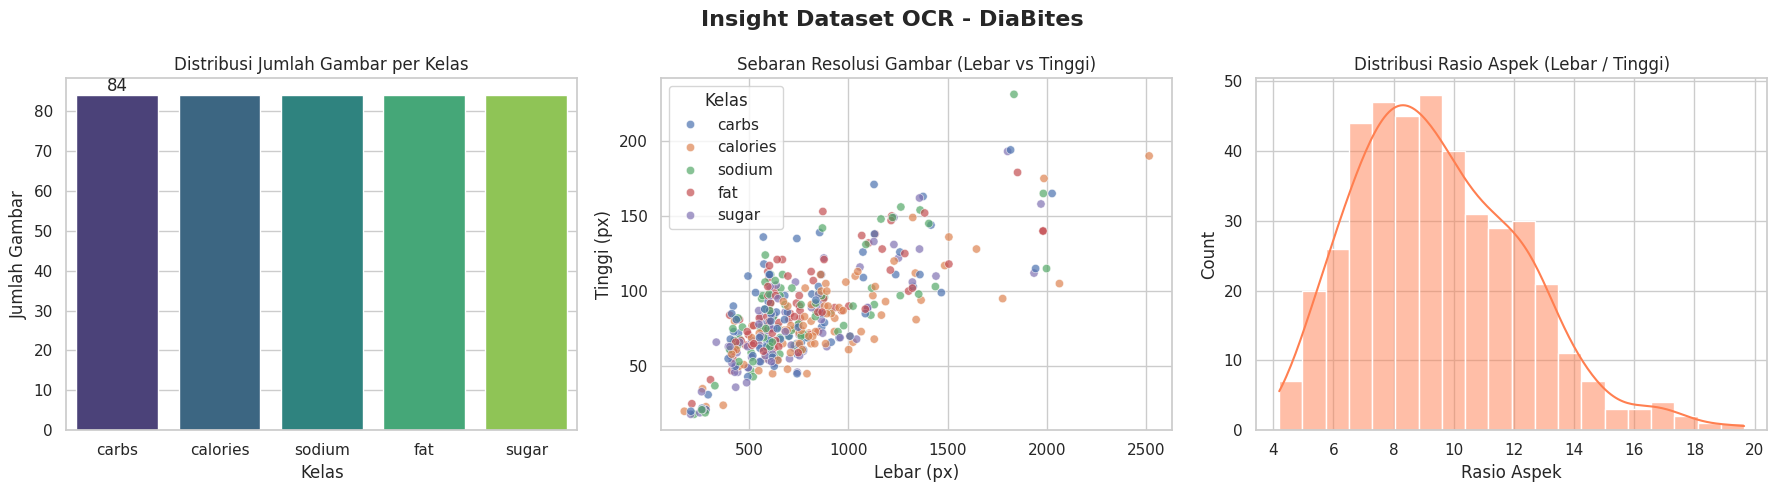

In [2]:

# 1. Konfigurasi Direktori
input_dir = r'/content/drive/MyDrive/STMIK /Coding Camp/Data/Data OCR/all_croping'
output_insight = r'/content/drive/MyDrive/STMIK /Coding Camp/Data/Data OCR/dataset_insight_dashboard.png'

data = []

print("=== MEMULAI ANALISIS DATASET OCR ===")

# 2. Ekstraksi Fitur dari Gambar
for file_name in os.listdir(input_dir):
    if not file_name.endswith(('.png', '.jpg', '.jpeg')): continue

    # Mengambil nama kelas dari nama file (misal: "carbs_001.png" -> "carbs")
    class_name = file_name.split('_')[0]

    img_path = os.path.join(input_dir, file_name)
    img = cv2.imread(img_path)

    if img is None: continue

    tinggi, lebar, _ = img.shape
    rasio_aspek = round(lebar / tinggi, 2)

    data.append({
        'File': file_name,
        'Kelas': class_name,
        'Lebar (px)': lebar,
        'Tinggi (px)': tinggi,
        'Rasio Aspek': rasio_aspek
    })

df = pd.DataFrame(data)

# 3. Membuat Visualisasi Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Insight Dataset OCR - DiaBites', fontsize=16, fontweight='bold')

# Grafik 1: Distribusi Kelas (Class Balance)
sns.countplot(data=df, x='Kelas', order=df['Kelas'].value_counts().index, ax=axes[0], palette="viridis")
axes[0].set_title('Distribusi Jumlah Gambar per Kelas')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].bar_label(axes[0].containers[0])

# Grafik 2: Sebaran Dimensi Gambar (Lebar vs Tinggi)
sns.scatterplot(data=df, x='Lebar (px)', y='Tinggi (px)', hue='Kelas', alpha=0.7, ax=axes[1])
axes[1].set_title('Sebaran Resolusi Gambar (Lebar vs Tinggi)')

# Grafik 3: Distribusi Rasio Aspek
sns.histplot(data=df, x='Rasio Aspek', bins=20, kde=True, ax=axes[2], color='coral')
axes[2].set_title('Distribusi Rasio Aspek (Lebar / Tinggi)')
axes[2].set_xlabel('Rasio Aspek')

plt.tight_layout()

# 4. Simpan dan Tampilkan
#plt.savefig(output_insight, dpi=300)
#print(f"✅ Dashboard insight berhasil disimpan di:\n{output_insight}")

In [3]:
# Cetak ringkasan statistik ke terminal
print("\n=== RINGKASAN STATISTIK ===")
print(f"Total Gambar : {len(df)}")
print(f"Rata-rata Tinggi : {df['Tinggi (px)'].mean():.0f} px")
print(f"Rata-rata Lebar  : {df['Lebar (px)'].mean():.0f} px")
print(f"Dimensi Terkecil : {df['Lebar (px)'].min()}x{df['Tinggi (px)'].min()} px")
print(f"Dimensi Terbesar : {df['Lebar (px)'].max()}x{df['Tinggi (px)'].max()} px")


=== RINGKASAN STATISTIK ===
Total Gambar : 420
Rata-rata Tinggi : 84 px
Rata-rata Lebar  : 782 px
Dimensi Terkecil : 173x18 px
Dimensi Terbesar : 2515x231 px
